In [1]:
# %matplotlib ipympl

In [2]:
import contextlib
import itertools
import multiprocessing as mp
from pathlib import Path

import numpy as np
import pandas as pd
import pyPPG
import pyPPG.example
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt
from tqdm import notebook, tqdm

In [3]:
csvs_dir = Path('csvs')

In [4]:
ppg_dir = Path('data/ppg')

In [5]:
pyppg_dir = Path('data/pyppg')

In [6]:
df_subjects = pd.read_csv(csvs_dir / 'subjects.csv')

In [7]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [8]:
fs = 125

In [9]:
def make_filter(design: str, wn: int):
    if design == 'cheby2':
        filt = scipy.signal.cheby2(4, 20, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'butter':
        filt = scipy.signal.butter(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'bessel':
        filt = scipy.signal.bessel(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    else:
        raise NotImplementedError
    return filt


designs = ['cheby2', 'butter', 'bessel']

wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]

In [10]:
df_iter = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(df_iter, designs, wns))):

    mat = scipy.io.loadmat(patient_file)

    # t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    t0 = 2 * 60 * fs
    t1 = t0 + 1 * 60 * fs
    ppg_raw = ppg_raw[t0:t1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    scipy.io.savemat((pyppg_dir / '2+1' / signal_file).as_posix(), {'Fs': fs, 'Data': ppg_filt})

100%|██████████| 1428/1428 [00:06<00:00, 223.87it/s]


In [30]:
metrics = {
    'na_sum': [],
    't_mean': [],
    't_std': [],
    's_mean': [],
    's_std': []
}

# df_iter = list(df_subjects.loc[:0, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# df_iter = list(df_subjects.sample(2, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
df_iter = list(df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False))

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(df_iter, designs, wns))):

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp, bm = pyPPG.example.ppg_example(
            data_path=(pyppg_dir / '2+1' / signal_file).as_posix(),
            process_type='fiducials',
            filtering=False,
            # filtering=True,
            # fL=0,
            # fH=30,
            print_flag=False,
            plotfig=False,
            savefig=False,
            savedata=False
        )

    name = (str(category), str(subject_id), str(design), str(wn))

    t_pts = fp.get_fp()

    na_sum = t_pts.isna().sum()
    na_sum.name = name
    metrics['na_sum'].append(na_sum)

    t_rel = (t_pts.T - t_pts['on']).T

    t_norm = (t_rel.T / t_rel['off']).T

    # plt.plot(s.v[:500])
    # for k in range(6):
    #     plt.scatter(t_pts['on'][k], s.v[t_pts['on'][k]])

    t_mean = t_norm.mean()
    t_mean.name = name
    metrics['t_mean'].append(t_mean)

    t_std = t_norm.std()
    t_std.name = name
    metrics['t_std'].append(t_std)

    s_pts = t_pts.map(lambda x: s.v[int(x)], na_action='ignore')

    s_mean = s_pts.mean()
    s_mean.name = name
    metrics['s_mean'].append(s_mean)

    s_std = s_pts.std()
    s_std.name = name
    metrics['s_std'].append(s_std)

dfs = {}
for metric, data in metrics.items():
    df = pd.DataFrame(data)
    df.index = df.index.set_names(['category', 'subject_id', 'design', 'wn'])
    dfs[metric] = df
dfs

100%|██████████| 1428/1428 [04:16<00:00,  5.57it/s]


{'na_sum':                                       on  sp  dn  dp  off  u  v  w  a  b  c  \
 category subject_id design wn                                                 
 control  48480      cheby2 10          0   0   0  99    0  0  0  0  0  0  1   
                            15          0   0   0  11    0  0  0  0  0  0  5   
                            20          0   0   0  18    0  0  3  3  0  0  4   
                            25          0   0   0  17    0  0  3  3  0  0  2   
                            30          0   0   0   7    0  0  2  2  0  0  2   
 ...                                   ..  ..  ..  ..  ... .. .. .. .. .. ..   
 diab     98484      bessel [0.5, 20]   0   0   0   0    0  0  0  0  0  0  0   
                            [0.5, 25]   0   0   0   0    0  0  0  0  0  0  0   
                            [0.5, 30]   0   0   0   0    0  0  0  0  0  0  0   
                            [0.5, 35]   0   0   0   0    0  0  0  0  0  0  0   
                            [0

In [31]:
with pd.option_context('display.max_rows', 500, 'display.precision', 2):
    for metric, df in dfs.items():
        # display(df.groupby(level=['design', 'wn']).mean())
        display(metric)
        display(df)

'na_sum'

on  sp  dn  dp  off  u  v  w  a  b  c  \
category subject_id design wn                                                 
control  48480      cheby2 10          0   0   0  99    0  0  0  0  0  0  1   
                           15          0   0   0  11    0  0  0  0  0  0  5   
                           20          0   0   0  18    0  0  3  3  0  0  4   
                           25          0   0   0  17    0  0  3  3  0  0  2   
                           30          0   0   0   7    0  0  2  2  0  0  2   
...                                   ..  ..  ..  ..  ... .. .. .. .. .. ..   
diab     98484      bessel [0.5, 20]   0   0   0   0    0  0  0  0  0  0  0   
                           [0.5, 25]   0   0   0   0    0  0  0  0  0  0  0   
                           [0.5, 30]   0   0   0   0    0  0  0  0  0  0  0   
                           [0.5, 35]   0   0   0   0    0  0  0  0  0  0  0   
                           [0.1, 30]   0   0   0   1    0  0  0  0  0  0  0   

                                      d  e  f  p1  p2  
category subject_id design wn                          
control  48480      cheby2 10         1  0  1   0   1  
                           15         5  0  5   0   5  
                           20         4  0  4   0   4  
                           25         2  0  2   0   2  
                           30         2  0  2   0   2  
...                                  .. .. ..  ..  ..  
diab     98484      bessel [0.5, 20]  0  0  0   0   0  
                           [0.5, 25]  0  0  0   0   0  
                           [0.5, 30]  0  0  0   0   0  
                           [0.5, 35]  0  0  0   0   0  
                           [0.1, 30]  0  0  0   0   0  

[1428 rows x 16 columns]

't_mean'

on    sp    dn    dp  off     u     v  \
category subject_id design wn                                                  
control  48480      cheby2 10         0.0  0.28  0.75  0.74  1.0  0.16  0.39   
                           15         0.0  0.23  0.63  0.69  1.0  0.19  0.39   
                           20         0.0  0.24  0.64  0.69  1.0  0.21  0.40   
                           25         0.0  0.24  0.65  0.69  1.0  0.19  0.38   
                           30         0.0  0.24  0.64  0.67  1.0  0.18  0.37   
...                                   ...   ...   ...   ...  ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.0  0.26  0.55  0.65  1.0  0.12  0.44   
                           [0.5, 25]  0.0  0.25  0.55  0.64  1.0  0.12  0.43   
                           [0.5, 30]  0.0  0.25  0.55  0.63  1.0  0.12  0.44   
                           [0.5, 35]  0.0  0.25  0.55  0.62  1.0  0.11  0.43   
                           [0.1, 30]  0.0  0.28  0.56  0.65  1.0  0.14  0.46   

                                         w     a     b     c     d     e  \
category subject_id design wn                                              
control  48480      cheby2 10         0.76  0.05  0.24  0.33  0.33  0.49   
                           15         0.64  0.07  0.21  0.30  0.35  0.49   
                           20         0.60  0.08  0.22  0.32  0.36  0.48   
                           25         0.57  0.07  0.20  0.30  0.35  0.48   
                           30         0.54  0.07  0.18  0.24  0.30  0.48   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.61  0.05  0.16  0.30  0.37  0.51   
                           [0.5, 25]  0.59  0.05  0.16  0.26  0.34  0.50   
                           [0.5, 30]  0.58  0.05  0.14  0.21  0.29  0.50   
                           [0.5, 35]  0.56  0.05  0.12  0.16  0.23  0.49   
                           [0.1, 30]  0.59  0.07  0.16  0.23  0.31  0.51   

                                         f    p1    p2  
category subject_id design wn                           
control  48480      cheby2 10         0.84  0.33  0.58  
                           15         0.67  0.27  0.44  
                           20         0.61  0.25  0.33  
                           25         0.57  0.23  0.32  
                           30         0.54  0.20  0.27  
...                                    ...   ...   ...  
diab     98484      bessel [0.5, 20]  0.64  0.20  0.31  
                           [0.5, 25]  0.62  0.19  0.29  
                           [0.5, 30]  0.59  0.16  0.25  
                           [0.5, 35]  0.57  0.14  0.19  
                           [0.1, 30]  0.61  0.18  0.27  

[1428 rows x 16 columns]

't_std'

on    sp    dn    dp  off     u     v  \
category subject_id design wn                                                  
control  48480      cheby2 10         0.0  0.03  0.05  0.04  0.0  0.05  0.04   
                           15         0.0  0.07  0.10  0.08  0.0  0.16  0.13   
                           20         0.0  0.08  0.09  0.09  0.0  0.18  0.13   
                           25         0.0  0.09  0.10  0.09  0.0  0.17  0.13   
                           30         0.0  0.09  0.10  0.09  0.0  0.16  0.13   
...                                   ...   ...   ...   ...  ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.0  0.03  0.04  0.03  0.0  0.04  0.03   
                           [0.5, 25]  0.0  0.03  0.04  0.03  0.0  0.04  0.03   
                           [0.5, 30]  0.0  0.03  0.04  0.04  0.0  0.04  0.02   
                           [0.5, 35]  0.0  0.03  0.04  0.05  0.0  0.04  0.03   
                           [0.1, 30]  0.0  0.03  0.04  0.04  0.0  0.04  0.02   

                                         w     a     b     c     d     e  \
category subject_id design wn                                              
control  48480      cheby2 10         0.04  0.05  0.04  0.03  0.03  0.03   
                           15         0.12  0.12  0.12  0.08  0.08  0.06   
                           20         0.12  0.12  0.12  0.09  0.08  0.07   
                           25         0.09  0.12  0.12  0.12  0.11  0.08   
                           30         0.09  0.11  0.12  0.13  0.13  0.07   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.04  0.04  0.04  0.05  0.05  0.03   
                           [0.5, 25]  0.05  0.04  0.04  0.07  0.08  0.03   
                           [0.5, 30]  0.05  0.04  0.05  0.08  0.11  0.03   
                           [0.5, 35]  0.06  0.04  0.05  0.07  0.10  0.04   
                           [0.1, 30]  0.05  0.04  0.05  0.08  0.11  0.03   

                                         f    p1    p2  
category subject_id design wn                           
control  48480      cheby2 10         0.06  0.04  0.07  
                           15         0.15  0.12  0.11  
                           20         0.14  0.12  0.08  
                           25         0.10  0.12  0.10  
                           30         0.09  0.13  0.12  
...                                    ...   ...   ...  
diab     98484      bessel [0.5, 20]  0.06  0.04  0.06  
                           [0.5, 25]  0.07  0.04  0.07  
                           [0.5, 30]  0.06  0.05  0.09  
                           [0.5, 35]  0.06  0.06  0.08  
                           [0.1, 30]  0.06  0.06  0.09  

[1428 rows x 16 columns]

's_mean'

on    sp    dn    dp   off     u  \
category subject_id design wn                                              
control  48480      cheby2 10         0.29  0.70  0.33  0.39  0.29  0.50   
                           15         0.29  0.71  0.34  0.46  0.29  0.49   
                           20         0.30  0.70  0.34  0.47  0.30  0.49   
                           25         0.30  0.70  0.34  0.46  0.30  0.49   
                           30         0.30  0.70  0.34  0.45  0.30  0.49   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20] -0.66  1.02 -0.23 -0.32 -0.67  0.11   
                           [0.5, 25] -0.66  1.01 -0.23 -0.30 -0.66  0.11   
                           [0.5, 30] -0.65  1.00 -0.23 -0.29 -0.66  0.10   
                           [0.5, 35] -0.65  0.99 -0.24 -0.27 -0.66  0.11   
                           [0.1, 30] -0.70  1.12 -0.21 -0.35 -0.71  0.14   

                                         v     w     a     b     c     d  \
category subject_id design wn                                              
control  48480      cheby2 10         0.59  0.34  0.30  0.68  0.67  0.67   
                           15         0.60  0.39  0.30  0.66  0.61  0.58   
                           20         0.60  0.41  0.31  0.66  0.60  0.57   
                           25         0.60  0.41  0.31  0.64  0.59  0.57   
                           30         0.60  0.42  0.31  0.58  0.58  0.61   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.37 -0.28 -0.58  0.64  0.95  0.72   
                           [0.5, 25]  0.37 -0.24 -0.57  0.58  0.89  0.72   
                           [0.5, 30]  0.36 -0.23 -0.57  0.42  0.69  0.72   
                           [0.5, 35]  0.36 -0.19 -0.56  0.24  0.48  0.75   
                           [0.1, 30]  0.44 -0.22 -0.59  0.48  0.79  0.84   

                                         e     f    p1    p2  
category subject_id design wn                                 
control  48480      cheby2 10         0.44  0.34  0.67  0.37  
                           15         0.39  0.42  0.70  0.45  
                           20         0.41  0.43  0.69  0.60  
                           25         0.40  0.43  0.68  0.60  
                           30         0.41  0.43  0.61  0.62  
...                                    ...   ...   ...   ...  
diab     98484      bessel [0.5, 20] -0.07 -0.28  0.86  0.90  
                           [0.5, 25] -0.04 -0.25  0.79  0.88  
                           [0.5, 30] -0.04 -0.23  0.59  0.77  
                           [0.5, 35] -0.02 -0.20  0.38  0.62  
                           [0.1, 30]  0.03 -0.23  0.67  0.89  

[1428 rows x 16 columns]

's_std'

on    sp    dn    dp   off     u  \
category subject_id design wn                                              
control  48480      cheby2 10         0.03  0.07  0.04  0.10  0.03  0.04   
                           15         0.03  0.07  0.04  0.17  0.03  0.05   
                           20         0.03  0.07  0.04  0.17  0.03  0.05   
                           25         0.03  0.07  0.04  0.17  0.03  0.05   
                           30         0.03  0.07  0.04  0.17  0.03  0.05   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.09  0.08  0.08  0.05  0.06  0.08   
                           [0.5, 25]  0.09  0.08  0.09  0.10  0.06  0.10   
                           [0.5, 30]  0.09  0.08  0.09  0.10  0.06  0.10   
                           [0.5, 35]  0.09  0.08  0.09  0.17  0.06  0.10   
                           [0.1, 30]  0.13  0.17  0.15  0.17  0.12  0.16   

                                         v     w     a     b     c     d  \
category subject_id design wn                                              
control  48480      cheby2 10         0.06  0.04  0.03  0.06  0.07  0.07   
                           15         0.06  0.09  0.03  0.06  0.12  0.15   
                           20         0.06  0.09  0.03  0.06  0.10  0.14   
                           25         0.07  0.09  0.03  0.07  0.09  0.14   
                           30         0.06  0.09  0.04  0.11  0.11  0.12   
...                                    ...   ...   ...   ...   ...   ...   
diab     98484      bessel [0.5, 20]  0.12  0.18  0.07  0.13  0.09  0.12   
                           [0.5, 25]  0.13  0.21  0.08  0.17  0.16  0.12   
                           [0.5, 30]  0.12  0.18  0.08  0.35  0.41  0.13   
                           [0.5, 35]  0.14  0.21  0.08  0.41  0.48  0.15   
                           [0.1, 30]  0.19  0.25  0.15  0.40  0.47  0.20   

                                         e     f    p1    p2  
category subject_id design wn                                 
control  48480      cheby2 10         0.05  0.04  0.07  0.05  
                           15         0.07  0.13  0.07  0.13  
                           20         0.09  0.12  0.07  0.14  
                           25         0.08  0.12  0.08  0.14  
                           30         0.09  0.11  0.12  0.12  
...                                    ...   ...   ...   ...  
diab     98484      bessel [0.5, 20]  0.17  0.18  0.15  0.12  
                           [0.5, 25]  0.21  0.21  0.21  0.11  
                           [0.5, 30]  0.18  0.17  0.41  0.28  
                           [0.5, 35]  0.22  0.20  0.47  0.37  
                           [0.1, 30]  0.24  0.25  0.45  0.33  

[1428 rows x 16 columns]

In [32]:
with pd.option_context('display.precision', 2):
    display(dfs['t_std'].groupby(level=['design', 'wn']).mean())

on    sp    dn    dp  off     u     v     w     a     b  \
design wn                                                                    
bessel 10         0.0  0.03  0.04  0.04  0.0  0.03  0.03  0.04  0.03  0.03   
       15         0.0  0.03  0.04  0.04  0.0  0.04  0.03  0.05  0.04  0.04   
       20         0.0  0.03  0.05  0.04  0.0  0.04  0.03  0.05  0.04  0.04   
       25         0.0  0.03  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       30         0.0  0.03  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       35         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       [0.1, 30]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 10]  0.0  0.03  0.04  0.04  0.0  0.03  0.03  0.03  0.03  0.03   
       [0.5, 12]  0.0  0.03  0.04  0.04  0.0  0.03  0.03  0.03  0.03  0.03   
       [0.5, 15]  0.0  0.03  0.04  0.04  0.0  0.04  0.03  0.04  0.04  0.04   
       [0.5, 20]  0.0  0.04  0.05  0.04  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 25]  0.0  0.04  0.06  0.05  0.0  0.06  0.04  0.05  0.05  0.05   
       [0.5, 30]  0.0  0.04  0.06  0.05  0.0  0.06  0.04  0.05  0.06  0.06   
       [0.5, 35]  0.0  0.04  0.06  0.06  0.0  0.06  0.04  0.05  0.06  0.06   
butter 10         0.0  0.03  0.05  0.05  0.0  0.04  0.03  0.04  0.04  0.04   
       15         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       20         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       25         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       30         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       35         0.0  0.04  0.06  0.06  0.0  0.05  0.04  0.05  0.05  0.06   
       [0.1, 30]  0.0  0.04  0.06  0.06  0.0  0.06  0.04  0.06  0.05  0.06   
       [0.5, 10]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.04  0.05  0.04   
       [0.5, 12]  0.0  0.04  0.05  0.04  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 15]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 20]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 25]  0.0  0.04  0.05  0.05  0.0  0.06  0.04  0.05  0.05  0.06   
       [0.5, 30]  0.0  0.04  0.06  0.05  0.0  0.06  0.04  0.05  0.05  0.06   
       [0.5, 35]  0.0  0.04  0.06  0.06  0.0  0.05  0.04  0.05  0.05  0.06   
cheby2 10         0.0  0.03  0.04  0.04  0.0  0.03  0.03  0.04  0.03  0.03   
       15         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       20         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       25         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       30         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       35         0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       [0.1, 30]  0.0  0.04  0.05  0.05  0.0  0.06  0.04  0.05  0.05  0.06   
       [0.5, 10]  0.0  0.03  0.04  0.04  0.0  0.04  0.03  0.04  0.04  0.03   
       [0.5, 12]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.04  0.05  0.04   
       [0.5, 15]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 20]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 25]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.05   
       [0.5, 30]  0.0  0.04  0.05  0.05  0.0  0.05  0.04  0.05  0.05  0.06   
       [0.5, 35]  0.0  0.04  0.06  0.05  0.0  0.05  0.04  0.05  0.05  0.06   

                     c     d     e     f    p1    p2  
design wn                                             
bessel 10         0.04  0.04  0.04  0.05  0.04  0.06  
       15         0.05  0.05  0.04  0.06  0.04  0.05  
       20         0.05  0.05  0.04  0.06  0.05  0.06  
       25         0.06  0.07  0.04  0.06  0.05  0.06  
       30         0.07  0.07  0.04  0.06  0.06  0.07  
       35         0.08  0.08  0.04  0.06  0.06  0.07  
       [0.1, 30]  0.07  0.08  0.04  0.06  0.06  0.07  
       [0.5, 10]  0.04  0.04  0.03  0.04  0.03  0.06  
       [0.5, 12]  0.04  0.04  0.03  

In [33]:
with pd.option_context('display.precision', 2):
    display(dfs['t_std'].groupby(level=['design']).mean())

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
design,,,,,,,,,,,,,,,,
bessel,0.0,0.03,0.05,0.04,0.0,0.04,0.04,0.05,0.04,0.05,0.06,0.06,0.04,0.06,0.05,0.06
butter,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.05,0.06,0.07,0.04,0.06,0.06,0.06
cheby2,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.05,0.06,0.06,0.04,0.06,0.05,0.06


In [34]:
with pd.option_context('display.precision', 2):
    display(dfs['t_std'].groupby(level=['wn']).mean())

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
wn,,,,,,,,,,,,,,,,
10,0.0,0.03,0.04,0.04,0.0,0.03,0.03,0.04,0.03,0.03,0.04,0.04,0.03,0.05,0.04,0.05
15,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.04,0.05,0.05,0.04,0.06,0.05,0.05
20,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.05,0.06,0.06,0.04,0.06,0.05,0.06
25,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.05,0.07,0.07,0.04,0.06,0.06,0.06
30,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.06,0.07,0.08,0.04,0.06,0.06,0.07
35,0.0,0.04,0.05,0.05,0.0,0.05,0.04,0.05,0.05,0.06,0.07,0.08,0.04,0.06,0.06,0.07
"[0.1, 30]",0.0,0.04,0.05,0.05,0.0,0.06,0.04,0.05,0.05,0.06,0.07,0.08,0.04,0.06,0.06,0.07
"[0.5, 10]",0.0,0.03,0.04,0.04,0.0,0.04,0.03,0.04,0.04,0.04,0.04,0.04,0.03,0.05,0.04,0.05
"[0.5, 12]",0.0,0.04,0.05,0.04,0.0,0.04,0.03,0.04,0.04,0.04,0.05,0.04,0.04,0.05,0.04,0.05


In [35]:
with pd.option_context('display.precision', 2):
    display(dfs['s_std'].groupby(level=['design', 'wn']).mean())

on    sp    dn    dp   off     u     v     w     a     b  \
design wn                                                                      
bessel 10         0.08  0.08  0.08  0.09  0.06  0.07  0.09  0.10  0.06  0.09   
       15         0.08  0.08  0.09  0.09  0.07  0.08  0.10  0.10  0.07  0.10   
       20         0.09  0.08  0.10  0.09  0.07  0.09  0.11  0.12  0.07  0.12   
       25         0.09  0.08  0.10  0.10  0.07  0.09  0.11  0.13  0.08  0.16   
       30         0.09  0.08  0.10  0.12  0.07  0.10  0.11  0.14  0.08  0.23   
       35         0.09  0.08  0.11  0.13  0.07  0.11  0.11  0.14  0.08  0.28   
       [0.1, 30]  0.08  0.08  0.10  0.11  0.07  0.10  0.11  0.13  0.08  0.23   
       [0.5, 10]  0.06  0.04  0.04  0.06  0.03  0.04  0.04  0.05  0.03  0.06   
       [0.5, 12]  0.06  0.04  0.04  0.06  0.03  0.04  0.05  0.05  0.04  0.06   
       [0.5, 15]  0.06  0.04  0.05  0.06  0.04  0.05  0.06  0.06  0.04  0.07   
       [0.5, 20]  0.06  0.04  0.06  0.09  0.04  0.06  0.07  0.09  0.04  0.09   
       [0.5, 25]  0.06  0.04  0.07  0.10  0.04  0.07  0.08  0.10  0.05  0.13   
       [0.5, 30]  0.06  0.04  0.07  0.10  0.04  0.07  0.08  0.11  0.05  0.21   
       [0.5, 35]  0.06  0.04  0.07  0.11  0.04  0.08  0.09  0.11  0.05  0.26   
butter 10         0.09  0.08  0.09  0.13  0.07  0.08  0.10  0.11  0.07  0.09   
       15         0.09  0.08  0.10  0.13  0.07  0.09  0.11  0.13  0.07  0.13   
       20         0.09  0.08  0.11  0.13  0.07  0.10  0.12  0.14  0.08  0.18   
       25         0.09  0.08  0.11  0.14  0.07  0.11  0.12  0.14  0.09  0.27   
       30         0.09  0.08  0.11  0.15  0.07  0.11  0.12  0.15  0.09  0.31   
       35         0.09  0.08  0.11  0.15  0.07  0.11  0.12  0.15  0.09  0.32   
       [0.1, 30]  0.10  0.10  0.12  0.16  0.09  0.13  0.13  0.16  0.11  0.31   
       [0.5, 10]  0.07  0.05  0.07  0.11  0.04  0.05  0.08  0.09  0.04  0.07   
       [0.5, 12]  0.07  0.05  0.07  0.11  0.04  0.06  0.08  0.10  0.05  0.08   
       [0.5, 15]  0.07  0.05  0.08  0.11  0.04  0.07  0.09  0.11  0.05  0.11   
       [0.5, 20]  0.07  0.05  0.08  0.11  0.04  0.08  0.09  0.12  0.06  0.16   
       [0.5, 25]  0.07  0.05  0.08  0.12  0.04  0.09  0.09  0.12  0.07  0.26   
       [0.5, 30]  0.07  0.05  0.09  0.13  0.04  0.10  0.10  0.13  0.07  0.30   
       [0.5, 35]  0.07  0.05  0.09  0.14  0.04  0.09  0.10  0.13  0.07  0.31   
cheby2 10         0.08  0.09  0.08  0.10  0.06  0.08  0.10  0.10  0.06  0.09   
       15         0.09  0.08  0.10  0.14  0.07  0.08  0.11  0.12  0.07  0.10   
       20         0.09  0.08  0.10  0.13  0.07  0.09  0.12  0.13  0.08  0.13   
       25         0.09  0.08  0.11  0.13  0.07  0.10  0.12  0.14  0.08  0.18   
       30         0.09  0.08  0.11  0.14  0.07  0.11  0.12  0.14  0.09  0.26   
       35         0.09  0.08  0.11  0.15  0.07  0.11  0.12  0.15  0.09  0.31   
       [0.1, 30]  0.09  0.10  0.12  0.14  0.08  0.12  0.12  0.14  0.10  0.27   
       [0.5, 10]  0.06  0.05  0.05  0.08  0.04  0.04  0.08  0.08  0.04  0.06   
       [0.5, 12]  0.07  0.05  0.06  0.11  0.04  0.05  0.07  0.09  0.04  0.06   
       [0.5, 15]  0.07  0.05  0.07  0.11  0.04  0.05  0.08  0.10  0.04  0.08   
       [0.5, 20]  0.07  0.05  0.08  0.11  0.04  0.07  0.09  0.11  0.05  0.12   
       [0.5, 25]  0.07  0.05  0.08  0.12  0.04  0.08  0.09  0.12  0.06  0.17   
       [0.5, 30]  0.07  0.05  0.08  0.12  0.04  0.09  0.09  0.12  0.06  0.26   
       [0.5, 35]  0.07  0.05  0.08  0.13  0.04  0.09  0.10  0.13  0.06  0.30   

                     c     d     e     f    p1    p2  
design wn                                             
bessel 10         0.13  0.13  0.10  0.10  0.09  0.17  
       15         0.14  0.14  0.11  0.11  0.09  0.15  
       20         0.16  0.15  0.13  0.12  0.12  0.16  
       25         0.19  0.17  0.13  0.13  0.17  0.16  
       30         0.25  0.18  0.14  0.14  0.25  0.21  
       35         0.30  0.17  0.15  0.14  0.32  0.26  
       [0.1, 30]  0.25  0.17  0.14  0.13  0.25  0.21  
    

In [36]:
with pd.option_context('display.precision', 2):
    display(dfs['s_std'].groupby(level=['design']).mean())

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
design,,,,,,,,,,,,,,,,
bessel,0.07,0.06,0.08,0.09,0.05,0.07,0.09,0.10,0.06,0.15,0.18,0.14,0.11,0.11,0.16,0.17
butter,0.08,0.07,0.09,0.13,0.06,0.09,0.10,0.13,0.07,0.21,0.23,0.15,0.14,0.13,0.22,0.20
cheby2,0.08,0.07,0.09,0.12,0.06,0.08,0.10,0.12,0.07,0.17,0.19,0.15,0.13,0.12,0.18,0.17


In [37]:
with pd.option_context('display.precision', 2):
    display(dfs['s_std'].groupby(level=['wn']).mean())

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
wn,,,,,,,,,,,,,,,,
10,0.08,0.08,0.08,0.11,0.07,0.07,0.09,0.10,0.06,0.09,0.12,0.12,0.10,0.10,0.09,0.15
15,0.09,0.08,0.10,0.12,0.07,0.08,0.11,0.12,0.07,0.11,0.14,0.15,0.13,0.12,0.11,0.15
20,0.09,0.08,0.10,0.12,0.07,0.09,0.11,0.13,0.08,0.14,0.17,0.16,0.14,0.13,0.15,0.16
25,0.09,0.08,0.10,0.12,0.07,0.10,0.12,0.14,0.08,0.20,0.23,0.17,0.14,0.14,0.22,0.19
30,0.09,0.08,0.11,0.13,0.07,0.11,0.12,0.14,0.09,0.27,0.28,0.17,0.15,0.15,0.29,0.23
35,0.09,0.08,0.11,0.14,0.07,0.11,0.12,0.15,0.09,0.30,0.31,0.17,0.16,0.15,0.33,0.27
"[0.1, 30]",0.09,0.10,0.11,0.14,0.08,0.12,0.12,0.14,0.10,0.27,0.29,0.18,0.15,0.15,0.30,0.23
"[0.5, 10]",0.06,0.05,0.05,0.08,0.04,0.04,0.07,0.08,0.04,0.06,0.09,0.10,0.08,0.08,0.06,0.12
"[0.5, 12]",0.07,0.05,0.06,0.09,0.04,0.05,0.07,0.08,0.04,0.07,0.11,0.11,0.08,0.09,0.07,0.13


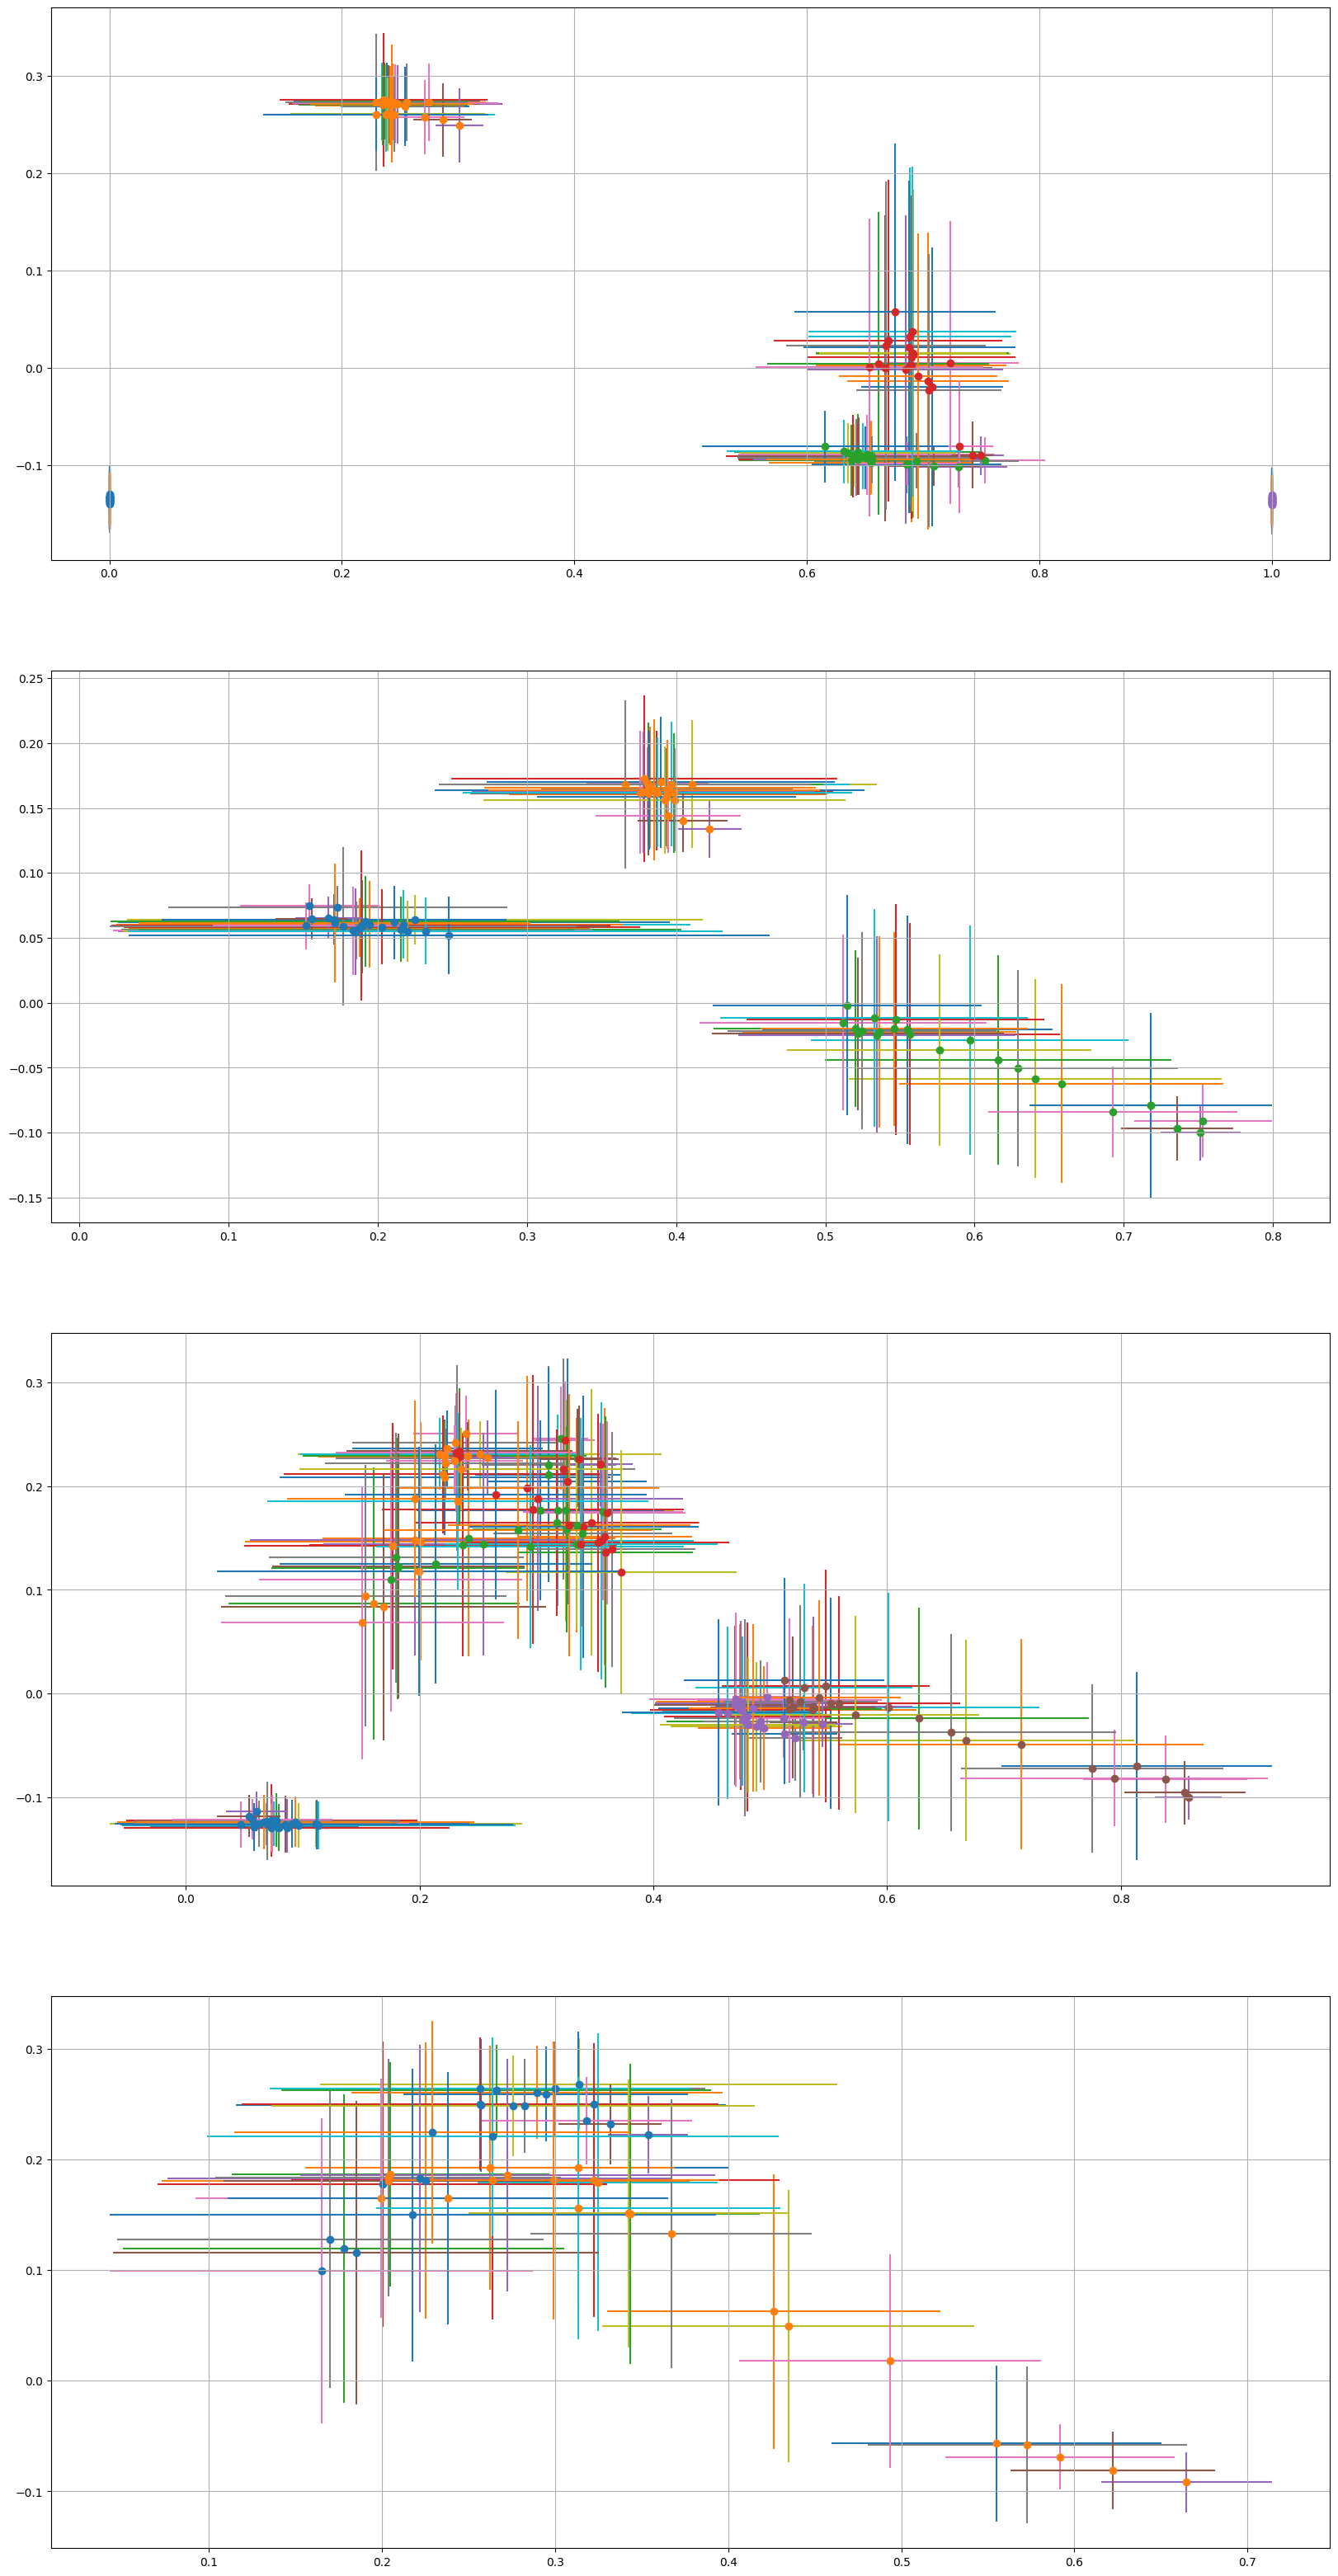

In [39]:
fig, axes = plt.subplots(4, 1, figsize=(20, 40))
axes: tuple[plt.Axes]

for k, ((subject_id, category, _), design, wn) in enumerate(itertools.product(df_iter, designs, wns)):
    if subject_id != df_iter[0][0]:
        continue
    if not isinstance(wn, list):
        continue
    for a, points in enumerate([['on', 'sp', 'dn', 'dp', 'off'], ['u', 'v', 'w'], ['a', 'b', 'c', 'd', 'e', 'f'], ['p1', 'p2']]):
        for m, p in enumerate(points):
            idx = (str(category), str(subject_id), str(design), str(wn))
            x = dfs['t_mean'].loc[idx, p]
            y = dfs['s_mean'].loc[idx, p]
            xerr = dfs['t_std'].loc[idx, p]
            yerr = dfs['s_std'].loc[idx, p]
            # axes[a].errorbar(x=x, y=y, xerr=xerr, yerr=yerr, linestyle='', color=f'C{k}', label=str(idx + (p,)), zorder=0)
            axes[a].errorbar(x=x, y=y, xerr=xerr, yerr=yerr, linestyle='', color=f'C{k}', zorder=0)
            # axes[a].legend([str(idx + (p,))])
            axes[a].scatter(x, y, color=f'C{m}', zorder=1)
        # axes[a].legend()
        axes[a].grid(visible=True)

In [40]:
# df_iter = list(df_subjects.loc[:0, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# df_iter = list(df_subjects.sample(2, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
df_iter = list(df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False))

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(df_iter, designs, wns))):

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp, bm = pyPPG.example.ppg_example(
            data_path=(pyppg_dir / '2+1' / signal_file).as_posix(),
            process_type='fiducials',
            filtering=False,
            # filtering=True,
            # fL=0,
            # fH=30,
            print_flag=False,
            plotfig=False,
            savefig=False,
            savedata=False
        )

    t_pts = fp.get_fp()

    print(t_pts)

    break

  0%|          | 0/1428 [00:00<?, ?it/s]

                  on    sp    dn    dp   off     u     v     w     a     b  \
Index of pulse                                                               
0                  1    41    56  <NA>    86    34    48    71    27    39   
1                 86   103   130   133   148    95   109   132    88   100   
2                148   165   211   226   270   157   171   219   150   162   
3                270   287   302  <NA>   332   279   294   317   273   285   
4                332   349   379  <NA>   394   341   355   379   334   346   
...              ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
110             6836  6853  6903  6915  6961  6907  6916  6946  6901  6913   
111             6961  6977  7003  7007  7022  6969  6984  7006  6963  6975   
112             7022  7039  7061  7068  7083  7031  7045  7067  7024  7037   
113             7083  7100  7130  <NA>  7145  7092  7107  7130  7085  7098   
114             7145  7162  7192  <NA>  7207  7154  7168  7192  